# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [3]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [4]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

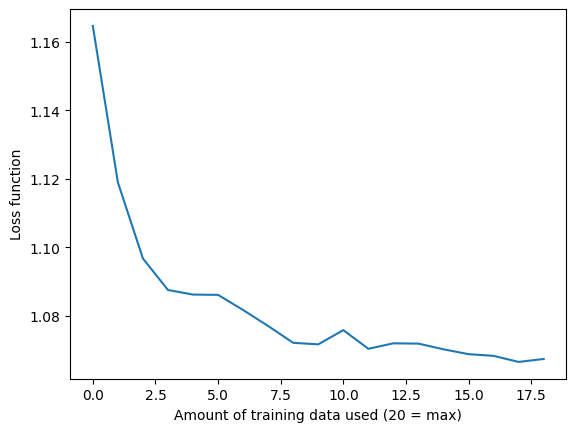

In [5]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [6]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

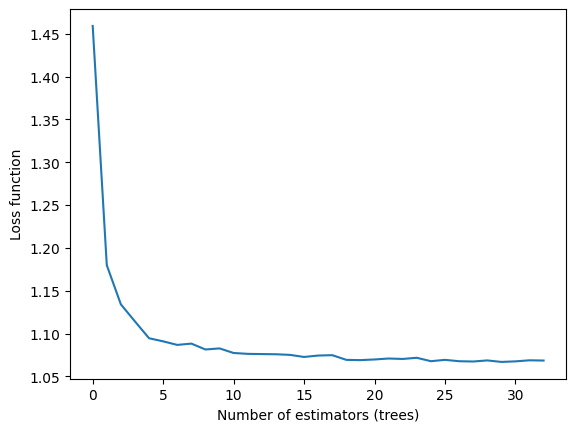

In [7]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

If I had to cut one of the two plots, I would remove the plot showing the number of estimators on the x-axis and keep the plot showing the amount of training data used. The training data plot is more important because it shows a meaningful and impactful trend where as the amount of training data increases, the model’s performance improves significantly at first and then levels off. This directly relates to model generalization and provides a clear insight into how additional data affects performance. In contrast, the number of estimators plot shows a relatively small improvement in performance after a certain point, with the curve flattening quickly. While it does demonstrate that increasing the number of trees can reduce error, the overall impact is much less significant compared to adding more training data. As a result, it is less interesting and less important for understanding the model’s behavior. Based on the principles of “keep it simple” and “have the guts to cut,” the training data plot should be kept because it communicates the most meaningful insight, while the number of estimators plot can be removed without losing much value. Overall, the amount of training data used is the more important variable to emphasize on the x-axis.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

def run_rf_analysis(df, target_col, name, n_iter=6, cv=3):
    print(f"\n===== {name} =====")

    y = df[target_col]
    X = df.drop(columns=[target_col])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0
    )

    param_dist = {
        "n_estimators": [50, 100],
        "max_depth": [None, 5, 10],
        "max_features": ["sqrt", 0.5],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }

    rs = RandomizedSearchCV(
        estimator=RandomForestRegressor(random_state=0),
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=cv,
        scoring="r2",
        n_jobs=-1,
        random_state=0
    )

    rs.fit(X_train, y_train)

    best_model = rs.best_estimator_
    preds = best_model.predict(X_test)

    corr = np.corrcoef(preds, y_test)[0, 1]
    r2 = r2_score(y_test, preds)

    print("Best Params:", rs.best_params_)
    print("CV R2:", rs.best_score_)
    print("Test Corr:", corr)
    print("Test R2:", r2)

    return {
        "name": name,
        "best_params": rs.best_params_,
        "cv_r2": rs.best_score_,
        "test_corr": corr,
        "test_r2": r2
    }

In [11]:
df_diabetes = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
df_diabetes_small = df_diabetes.sample(n=5000, random_state=0)

res_diabetes = run_rf_analysis(
    df_diabetes_small,
    "Diabetes_012",
    "Diabetes"
)


===== Diabetes =====
Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 5}
CV R2: 0.1861897330112718
Test Corr: 0.4033187747226932
Test R2: 0.16038898723354666


In [12]:
df_alz = pd.read_csv("alzheimers_disease_data.csv")
df_alz = df_alz.drop(columns=["DoctorInCharge"])

res_alz = run_rf_analysis(
    df_alz,
    "Diagnosis",
    "Alzheimer's"
)


===== Alzheimer's =====
Best Params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': None}
CV R2: 0.8158080862509053
Test Corr: 0.9419132372114165
Test R2: 0.8836346942100053


In [17]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

chronic_kidney_disease = fetch_ucirepo(id=336)

X_ckd = chronic_kidney_disease.data.features.copy()
y_ckd = chronic_kidney_disease.data.targets.copy()

print("Target columns:", y_ckd.columns.tolist())
print("Unique target values:")
print(y_ckd.iloc[:, 0].astype(str).str.strip().unique())

# Rename target safely
target_col = "class"
y_ckd.columns = [target_col]

# Combine
df_ckd = pd.concat([X_ckd, y_ckd], axis=1)

# Clean missing values
df_ckd = df_ckd.replace("?", np.nan).dropna()

# Map target to numeric
df_ckd[target_col] = df_ckd[target_col].astype(str).str.strip().map({
    "ckd": 1,
    "notckd": 0,
    "not ckd": 0
})

# Drop any rows that failed mapping
df_ckd = df_ckd.dropna(subset=[target_col])

# One-hot encode predictors only
X_ckd_clean = pd.get_dummies(df_ckd.drop(columns=[target_col]), drop_first=True)
df_ckd_clean = pd.concat([X_ckd_clean, df_ckd[target_col]], axis=1)

res_ckd = run_rf_analysis(
    df_ckd_clean,
    target_col,
    "Chronic Kidney Disease"
)

Target columns: ['class']
Unique target values:
<StringArray>
['ckd', 'notckd']
Length: 2, dtype: str

===== Chronic Kidney Disease =====
Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 5}
CV R2: 0.9520116705261533
Test Corr: 0.966752206006659
Test R2: 0.9305833333333333


In [19]:
print("\nSummary of results:")
print(res_diabetes)
print(res_alz)
print(res_ckd)


Summary of results:
{'name': 'Diabetes', 'corr': np.float64(0.4033187747226932), 'r2': 0.16038898723354666}
{'name': "Alzheimer's", 'corr': np.float64(0.9419132372114165), 'r2': 0.8836346942100053}
{'name': 'Chronic Kidney Disease', 'corr': np.float64(0.966752206006659), 'r2': 0.9305833333333333}


I applied the same random forest pipeline across the diabetes, Alzheimer’s, and chronic kidney disease datasets, using train-test splits, RandomizedSearchCV for hyperparameter tuning, and evaluation with correlation and R^2. The results show clear differences in how well each dataset can be modeled. The diabetes dataset had relatively low performance, with a test correlation of about 0.40 and an R^2 of about 0.16. This suggests that while there is some structure in the data, diabetes outcomes are harder to predict from the available features, likely because the underlying relationships are more complex or influenced by factors not captured in the dataset. In contrast, the Alzheimer’s dataset performed much better, with a test correlation of about 0.94 and an R^2 of about 0.88. This indicates that the model was able to capture strong patterns in the data, likely because the features are more directly related to the diagnosis. The chronic kidney disease dataset showed the strongest performance, with a test correlation of about 0.97 and an R^2 of about 0.93. This suggests that the dataset contains very clear and predictive features, making the target variable much easier for the model to learn. Overall, this comparison shows that random forest performs significantly better when there is strong structure and direct relationships in the data. Cleaner datasets with more relevant features lead to higher predictive performance, while more complex or noisy datasets are harder to model accurately.

I used R^2 as the main scoring metric because it is easy to interpret and allows for direct comparison across datasets. R^2 measures how much of the variation in the target variable is explained by the model. A value close to 1 indicates strong predictive performance, while a value closer to 0 suggests that the model is not capturing much of the underlying structure. In this case, the large difference in R^2 values across the three datasets clearly highlights how model performance depends on the quality and structure of the data.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

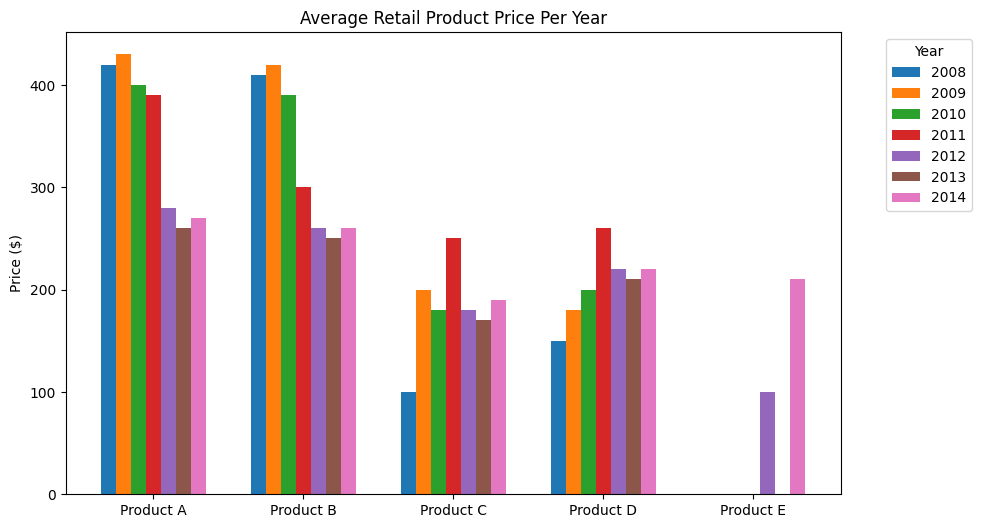

In [20]:
import matplotlib.pyplot as plt
import numpy as np

products = ["Product A", "Product B", "Product C", "Product D", "Product E"]
years = ["2008", "2009", "2010", "2011", "2012", "2013", "2014"]

data = {
    "2008": [420, 410, 100, 150, 0],
    "2009": [430, 420, 200, 180, 0],
    "2010": [400, 390, 180, 200, 0],
    "2011": [390, 300, 250, 260, 0],
    "2012": [280, 260, 180, 220, 100],
    "2013": [260, 250, 170, 210, 0],
    "2014": [270, 260, 190, 220, 210],
}

x = np.arange(len(products))
width = 0.1

plt.figure(figsize=(10,6))

for i, year in enumerate(years):
    plt.bar(x + i*width, data[year], width, label=year)

plt.xticks(x + width*3, products)
plt.ylabel("Price ($)")
plt.title("Average Retail Product Price Per Year")

plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()